# Geodesics in Heat on a Grid

The squared Euclidean Gibbs kernel used by Sinkhorn is a heat kernel on a flat grid.  On a manifold, Varadhan's formula says that the short-time heat kernel carries geodesic distance information,
$$
    -4t \log h_t(x,y) \longrightarrow d(x,y)^2.
$$
The geodesics-in-heat method first diffuses a few source points, then recovers an approximate distance by solving a Poisson equation driven by the normalized heat gradient.  This notebook illustrates a one-step backward-Euler resolvent approximation on a simple two-dimensional uniform grid, so the displayed parameter is the resolvent scale $\tau$ rather than the heat time $t$.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy import sparse
from scipy.sparse.linalg import spsolve

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import RED, BLUE, VIOLET, GRAY, figure_dir, save_pdf, setup_matplotlib, remove_axes

setup_matplotlib()

NAME = "sinkhorn-geodesics-in-heat"
OUT = figure_dir(NAME)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)


## Discrete heat and Poisson solves

The grid Laplacian below uses reflecting, or Neumann, boundary conditions.  For each resolvent scale $\tau$, we solve a backward-Euler step
$$
    (I+\tau L)u = u_0, \qquad L \simeq -\Delta.
$$
A single resolvent step behaves like a Laplace/Yukawa-type smoothing, while repeated steps approximate the Gaussian heat semigroup.  We then normalize the vector field $X=-\nabla u/|\nabla u|$ and solve $L\phi=-\operatorname{div}X$.  The additive constant is fixed afterwards by anchoring the distance at the source site.

In [2]:
n = 128
x = np.linspace(0.0, 1.0, n)
h = x[1] - x[0]
Xg, Yg = np.meshgrid(x, x)

sites = np.array([[0.24, 0.27], [0.72, 0.36], [0.45, 0.76]])
site_ij = [(int(round(s[1] / h)), int(round(s[0] / h))) for s in sites]


def lap1d_neumann(n, h):
    main = np.full(n, 2.0 / h**2)
    off = np.full(n - 1, -1.0 / h**2)
    main[0] = main[-1] = 1.0 / h**2
    return sparse.diags([off, main, off], [-1, 0, 1], format="csr")

L1 = lap1d_neumann(n, h)
I = sparse.eye(n, format="csr")
L = sparse.kron(I, L1, format="csr") + sparse.kron(L1, I, format="csr")
Id = sparse.eye(n * n, format="csr")

# Smooth impulses avoid a pixel-scale singularity while keeping the source localized.
sigma0 = 1.35 * h
u0 = np.zeros((n, n))
for sx, sy in sites:
    u0 += np.exp(-((Xg - sx) ** 2 + (Yg - sy) ** 2) / (2 * sigma0**2))
u0 /= max(u0.max(), 1e-15)

exact = np.min(np.sqrt((Xg[..., None] - sites[:, 0]) ** 2 + (Yg[..., None] - sites[:, 1]) ** 2), axis=2)


In [3]:
def resolvent_distance_single(tau, site_index):
    source = np.zeros_like(u0)
    i, j = site_ij[site_index]
    sx, sy = sites[site_index]
    source += np.exp(-((Xg - sx) ** 2 + (Yg - sy) ** 2) / (2 * sigma0**2))
    source /= max(source.max(), 1e-15)

    u = spsolve(Id + tau * L, source.ravel()).reshape(n, n)
    uy, ux = np.gradient(u, h, h, edge_order=2)
    norm = np.sqrt(ux**2 + uy**2 + 1e-18)
    vx = -ux / norm
    vy = -uy / norm
    div = np.gradient(vx, h, axis=1, edge_order=2) + np.gradient(vy, h, axis=0, edge_order=2)

    A = L.tolil()
    b = (-div).ravel()
    # Anchor at the source point to remove the additive nullspace.
    anchor = i * n + j
    A[anchor, :] = 0.0
    A[anchor, anchor] = 1.0
    b[anchor] = 0.0
    phi = spsolve(A.tocsr(), b).reshape(n, n)
    phi -= float(phi[i, j])
    phi = np.maximum(phi, 0.0)
    return phi


def resolvent_distance(tau):
    fields = [resolvent_distance_single(tau, k) for k in range(len(sites))]
    return np.min(np.stack(fields, axis=0), axis=0)

taus = [(0.00018, "tau-small"), (0.00055, "tau-medium"), (0.0016, "tau-large")]
approx = [(name, resolvent_distance(tau)) for tau, name in taus]

# Align the approximations to the exact scale by a robust least-square factor.
mask = exact > 4 * h
for k, (name, phi) in enumerate(approx):
    scale = float(np.sum(exact[mask] * phi[mask]) / np.sum(phi[mask] ** 2))
    approx[k] = (name, scale * phi)


## Exported panels

The panels use the same source points, while each color range is robustly normalized to reveal its own level-set geometry.  Larger resolvent scales $\tau$ are more stable but blur the small-scale geometry of the level sets.

In [4]:
cmap = LinearSegmentedColormap.from_list(
    "ot_distance", ["#ffffff", "#ead5dc", "#b98ac5", VIOLET, BLUE]
)
def panel_scale(field):
    vmax = float(np.quantile(field, 0.965))
    levels = np.linspace(0.12 * vmax, vmax, 8)
    return vmax, levels


def draw_field(field, filename):
    fig, ax = plt.subplots(figsize=(2.15, 2.15))
    ax.imshow(
        np.minimum(field, panel_scale(field)[0]),
        origin="lower",
        extent=(0, 1, 0, 1),
        cmap=cmap,
        vmin=0,
        vmax=panel_scale(field)[0],
        interpolation="bilinear",
    )
    ax.contour(Xg, Yg, field, levels=panel_scale(field)[1], colors="#2d2d2d", linewidths=0.34, alpha=0.55)
    ax.scatter(sites[:, 0], sites[:, 1], s=16, marker="o", color=RED, edgecolor="white", linewidth=0.35, zorder=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.018)
    plt.close(fig)

fields = [("exact", exact)] + approx
for name, field in fields:
    draw_field(field, f"{name}.pdf")

fig, axes = plt.subplots(1, 4, figsize=(7.6, 2.0))
for ax, (_, field) in zip(axes, fields):
    local_vmax, local_levels = panel_scale(field)
    ax.imshow(np.minimum(field, local_vmax), origin="lower", extent=(0, 1, 0, 1), cmap=cmap, vmin=0, vmax=local_vmax, interpolation="bilinear")
    ax.contour(Xg, Yg, field, levels=local_levels, colors="#2d2d2d", linewidths=0.32, alpha=0.55)
    ax.scatter(sites[:, 0], sites[:, 1], s=16, marker="o", color=RED, edgecolor="white", linewidth=0.35, zorder=4)
    ax.set_aspect("equal")
    remove_axes(ax)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.02, wspace=0.03)
fig.savefig(THUMB_DIR / f"{NAME}.png", dpi=180)
plt.close(fig)


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

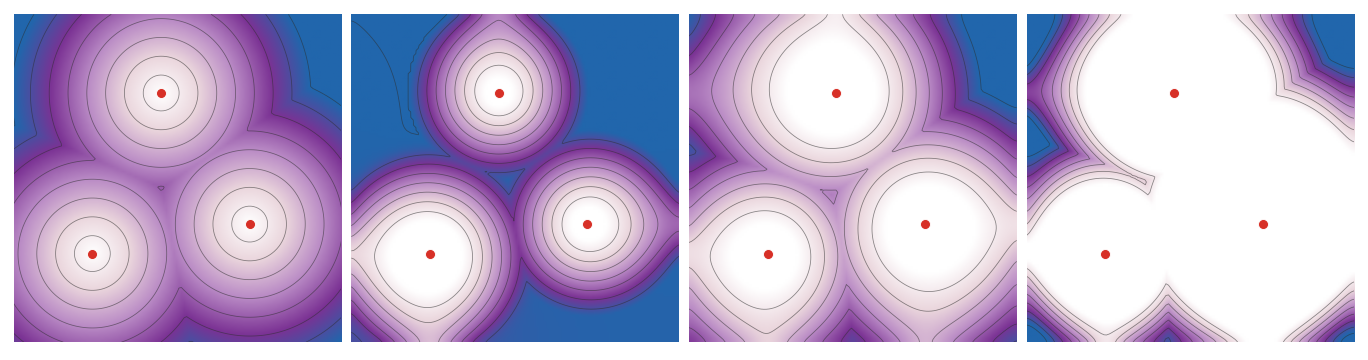

In [5]:
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-geodesics-in-heat.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-geodesics-in-heat.png")
display(Image(filename=str(_thumb)))
